In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [2]:
df = pd.read_csv("stock_prices.csv")

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()


,Close_Price
Date,
2024-01-01,101.493428
2024-01-02,101.716900
2024-01-03,103.512277
2024-01-04,107.058336
2024-01-05,107.090030


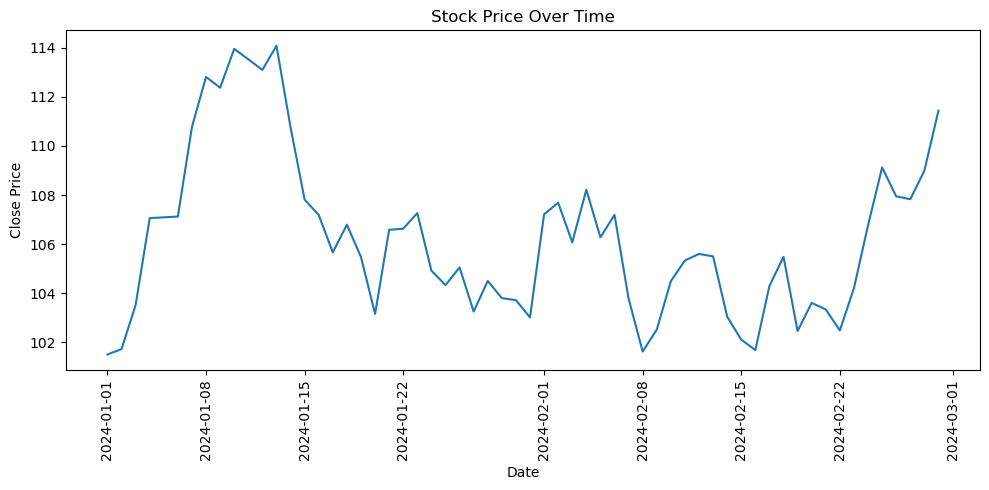

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df["Close_Price"])
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=90)

plt.tight_layout()  
plt.show()


In [22]:
df = df.asfreq("D")

train = df.iloc[:-10]
test = df.iloc[-10:]

In [23]:
model = ARIMA(train["Close_Price"], order=(1,1,1))
model_fit = model.fit()

model_fit.summary()



/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Close_Price   No. Observations:                   50
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -97.525
Date:                Tue, 17 Feb 2026   AIC                            201.050
Time:                        23:08:59   BIC                            206.725
Sample:                    01-01-2024   HQIC                           203.203
                         - 02-19-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7516      0.179     -4.209      0.000      -1.102      -0.402
ma.L1          0.9993      5.193      0.192      0.847      -9.179      11.177
sigma2         3.0087     15.435      0.195      0.845     -27.244      33.261
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 0.29
Prob(Q):                              0.62   Prob(JB):                         0.87
Heteroskedasticity (H):               1.04   Skew:                             0.19
Prob(H) (two-sided):                  0.94   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
forecast = model_fit.forecast(steps=10)
forecast


2024-02-20    101.761263
2024-02-21    102.280910
2024-02-22    101.890320
2024-02-23    102.183905
2024-02-24    101.963233
2024-02-25    102.129100
2024-02-26    102.004427
2024-02-27    102.098137
2024-02-28    102.027700
2024-02-29    102.080644
Freq: D, Name: predicted_mean, dtype: float64

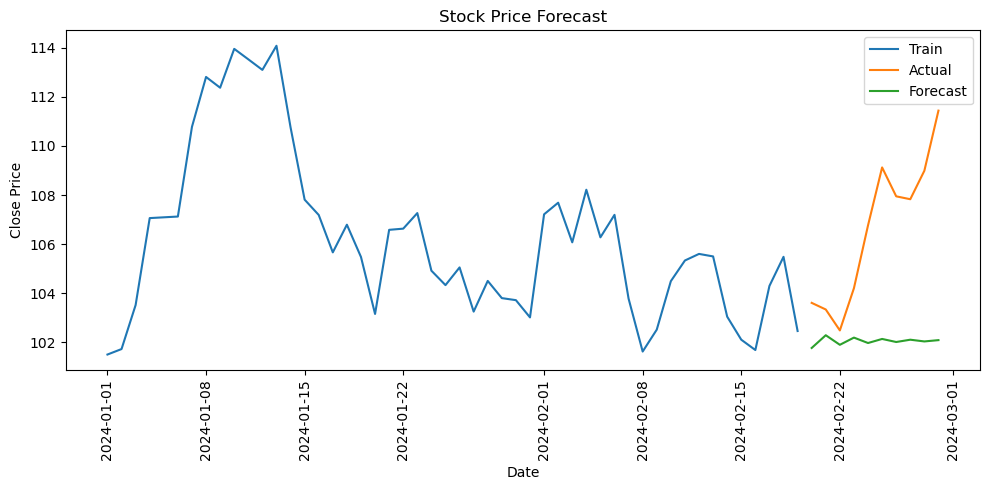

In [19]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train["Close_Price"], label="Train")
plt.plot(test.index, test["Close_Price"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()

plt.xticks(rotation=90)

plt.tight_layout()   
plt.show()
